# Intelligent Patient Risk Assessment  
## Notebook 01 — Data Understanding & Preprocessing

This notebook performs comprehensive data inspection, cleaning, statistical analysis, and preprocessing to prepare the healthcare dataset for downstream modeling.

In [1]:
# Install (Colab safe)
!pip -q install seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
from google.colab import files

print("Please upload your dataset CSV file")
uploaded = files.upload()

Please upload your dataset CSV file


Saving final_data.csv to final_data.csv


In [3]:
import io

# Get uploaded filename automatically
file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(f"Dataset '{file_name}' loaded successfully")
df.head()

Dataset 'final_data.csv' loaded successfully


,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,hypertension_risk_score,heart_disease_risk_score,obesity_risk_score,cholesterol_risk_score
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,145,136,236,6.36,8.18,51.716583,53.581369,50.796020,57.387241,51.492983
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,30,93,150,2.00,5.63,26.096162,47.946740,23.853485,36.219202,3.984993
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,36,118,195,5.07,7.51,54.830087,42.141104,38.977694,42.898797,21.793300
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,140,139,253,5.28,9.03,60.729521,60.286946,53.579555,52.194082,22.962029
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,160,137,184,12.74,7.20,32.778085,15.279074,18.721942,32.095465,34.296907


###  Objective

Build a machine learning system to predict patient heart disease risk using demographic, clinical, and laboratory features.

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 97297
Columns: 33


In [5]:
df.columns.tolist()

['Age',
 'gender',
 'ethnicity',
 'education_level',
 'income_level',
 'employment_status',
 'smoking_status',
 'alcohol_consumption_per_week',
 'physical_activity_minutes_per_week',
 'diet_score',
 'sleep_hours_per_day',
 'screen_time_hours_per_day',
 'family_history_diabetes',
 'hypertension_history',
 'cardiovascular_history',
 'bmi',
 'waist_to_hip_ratio',
 'systolic_bp',
 'diastolic_bp',
 'heart_rate',
 'cholesterol_total',
 'hdl_cholesterol',
 'ldl_cholesterol',
 'triglycerides',
 'glucose_fasting',
 'glucose_postprandial',
 'insulin_level',
 'hba1c',
 'diabetes_risk_score',
 'hypertension_risk_score',
 'heart_disease_risk_score',
 'obesity_risk_score',
 'cholesterol_risk_score']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97297 entries, 0 to 97296
Data columns (total 33 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 97297 non-null  int64  
 1   gender                              97297 non-null  object 
 2   ethnicity                           97297 non-null  object 
 3   education_level                     97297 non-null  object 
 4   income_level                        97297 non-null  object 
 5   employment_status                   97297 non-null  object 
 6   smoking_status                      97297 non-null  object 
 7   alcohol_consumption_per_week        97297 non-null  int64  
 8   physical_activity_minutes_per_week  97297 non-null  int64  
 9   diet_score                          97297 non-null  float64
 10  sleep_hours_per_day                 97297 non-null  float64
 11  screen_time_hours_per_day           97297

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,97297.0,50.192699,15.492557,19.000000,38.000000,51.000000,61.000000,90.000000
alcohol_consumption_per_week,97297.0,2.004543,1.418060,0.000000,1.000000,2.000000,3.000000,10.000000
physical_activity_minutes_per_week,97297.0,118.942886,84.441920,0.000000,57.000000,100.000000,160.000000,833.000000
diet_score,97297.0,5.995214,1.780096,0.000000,4.800000,6.000000,7.200000,10.000000
sleep_hours_per_day,97297.0,6.997708,1.093726,3.000000,6.300000,7.000000,7.700000,10.000000
screen_time_hours_per_day,97297.0,5.997031,2.469805,0.500000,4.300000,6.000000,7.700000,16.800000
family_history_diabetes,97297.0,0.219657,0.414017,0.000000,0.000000,0.000000,0.000000,1.000000
hypertension_history,97297.0,0.250912,0.433540,0.000000,0.000000,0.000000,1.000000,1.000000
cardiovascular_history,97297.0,0.079067,0.269845,0.000000,0.000000,0.000000,0.000000,1.000000
bmi,97297.0,25.615093,3.588387,15.000000,23.200000,25.600000,28.000000,39.200000


In [8]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [10]:
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed")
else:
    print("No duplicates found")

No duplicates found


In [11]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

,0


In [40]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent[missing_percent > 0].sort_values(ascending=False)

,0


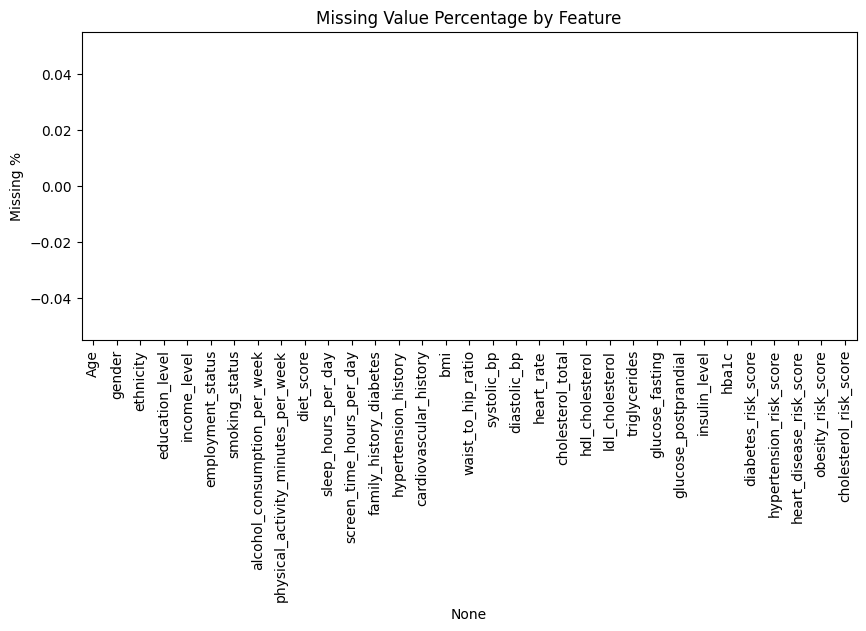

In [13]:
plt.figure(figsize=(10,4))
sns.barplot(x=missing_df.index, y=missing_df["Missing %"])
plt.xticks(rotation=90)
plt.title("Missing Value Percentage by Feature")
plt.show()

In [41]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numeric columns: 27
Categorical columns: 6


In [42]:
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

print("Numeric missing values handled")

Numeric missing values handled


In [43]:
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Categorical missing values handled")

Categorical missing values handled


In [14]:
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [45]:
df['heart_disease_risk_score'].describe()

,heart_disease_risk_score
count,97297.000000
mean,32.063255
std,15.412755
min,0.000000
25%,20.389335
50%,30.793098
75%,42.564698
max,97.902483


## Advanced Data Quality Checks & Statistical Analysis

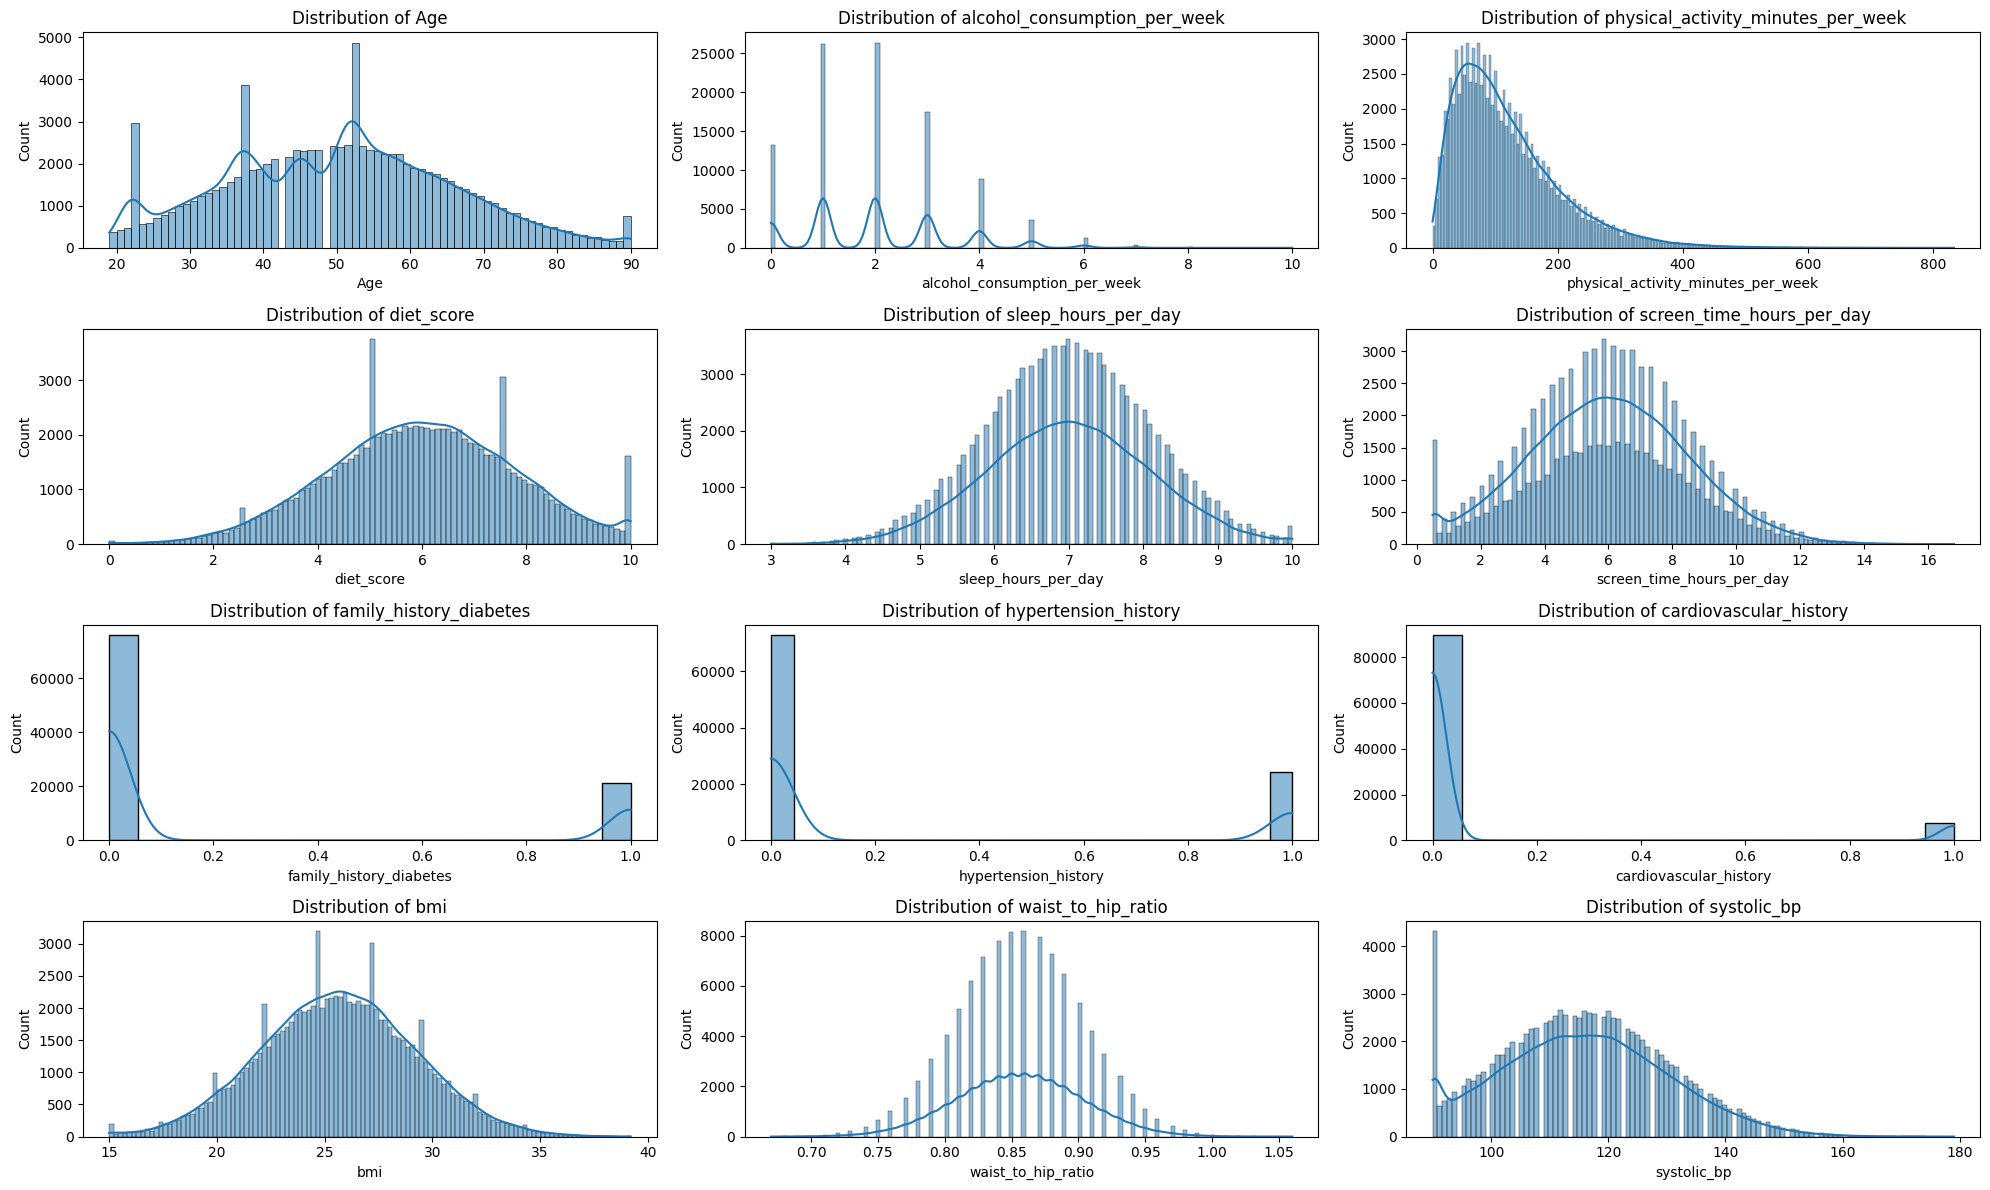

Distribution analysis completed


In [15]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(20, 12))

for i, col in enumerate(numeric_cols[:12], 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

print("Distribution analysis completed")

,Feature,Skewness
0,cardiovascular_history,3.119876
1,physical_activity_minutes_per_week,1.390451
2,family_history_diabetes,1.354286
3,hypertension_history,1.149111
4,alcohol_consumption_per_week,0.702080
5,insulin_level,0.423257
6,heart_disease_risk_score,0.363261
7,ldl_cholesterol,0.319729
8,cholesterol_risk_score,0.314396
9,systolic_bp,0.219172


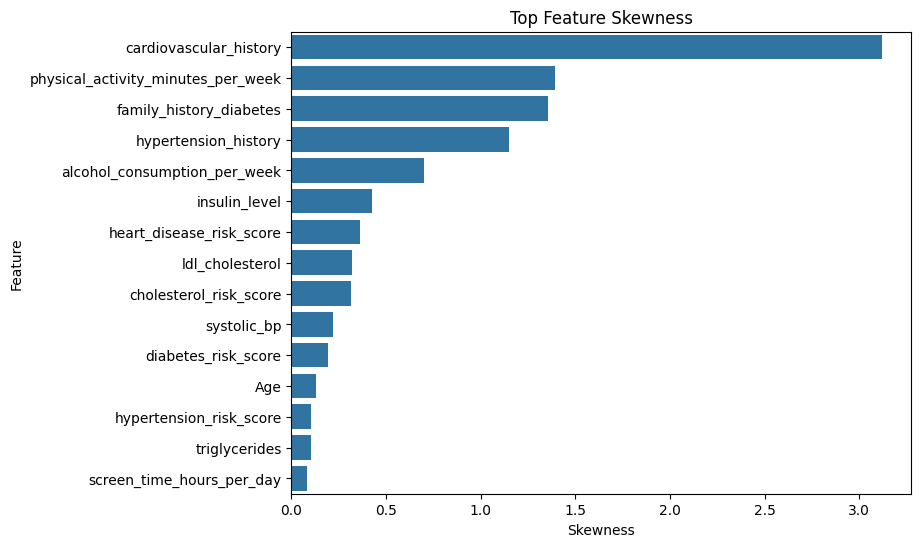

Skewness analysis completed


In [16]:
skewness = df[numeric_cols].skew().sort_values(ascending=False)

skew_df = pd.DataFrame({
    "Feature": skewness.index,
    "Skewness": skewness.values
})

display(skew_df)

plt.figure(figsize=(8,6))
sns.barplot(x="Skewness", y="Feature", data=skew_df.head(15))
plt.title("Top Feature Skewness")
plt.show()

print("Skewness analysis completed")

In [17]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers)

outlier_summary = {}

for col in numeric_cols:
    outlier_summary[col] = detect_outliers_iqr(df, col)

outlier_df = pd.DataFrame.from_dict(
    outlier_summary,
    orient='index',
    columns=['Outlier Count']
)

display(outlier_df.sort_values(by='Outlier Count', ascending=False))

print("Outlier detection completed")

,Outlier Count
family_history_diabetes,21372
cardiovascular_history,7693
physical_activity_minutes_per_week,3115
sleep_hours_per_day,870
heart_rate,836
bmi,729
glucose_fasting,722
diastolic_bp,717
glucose_postprandial,617
hba1c,599


Outlier detection completed


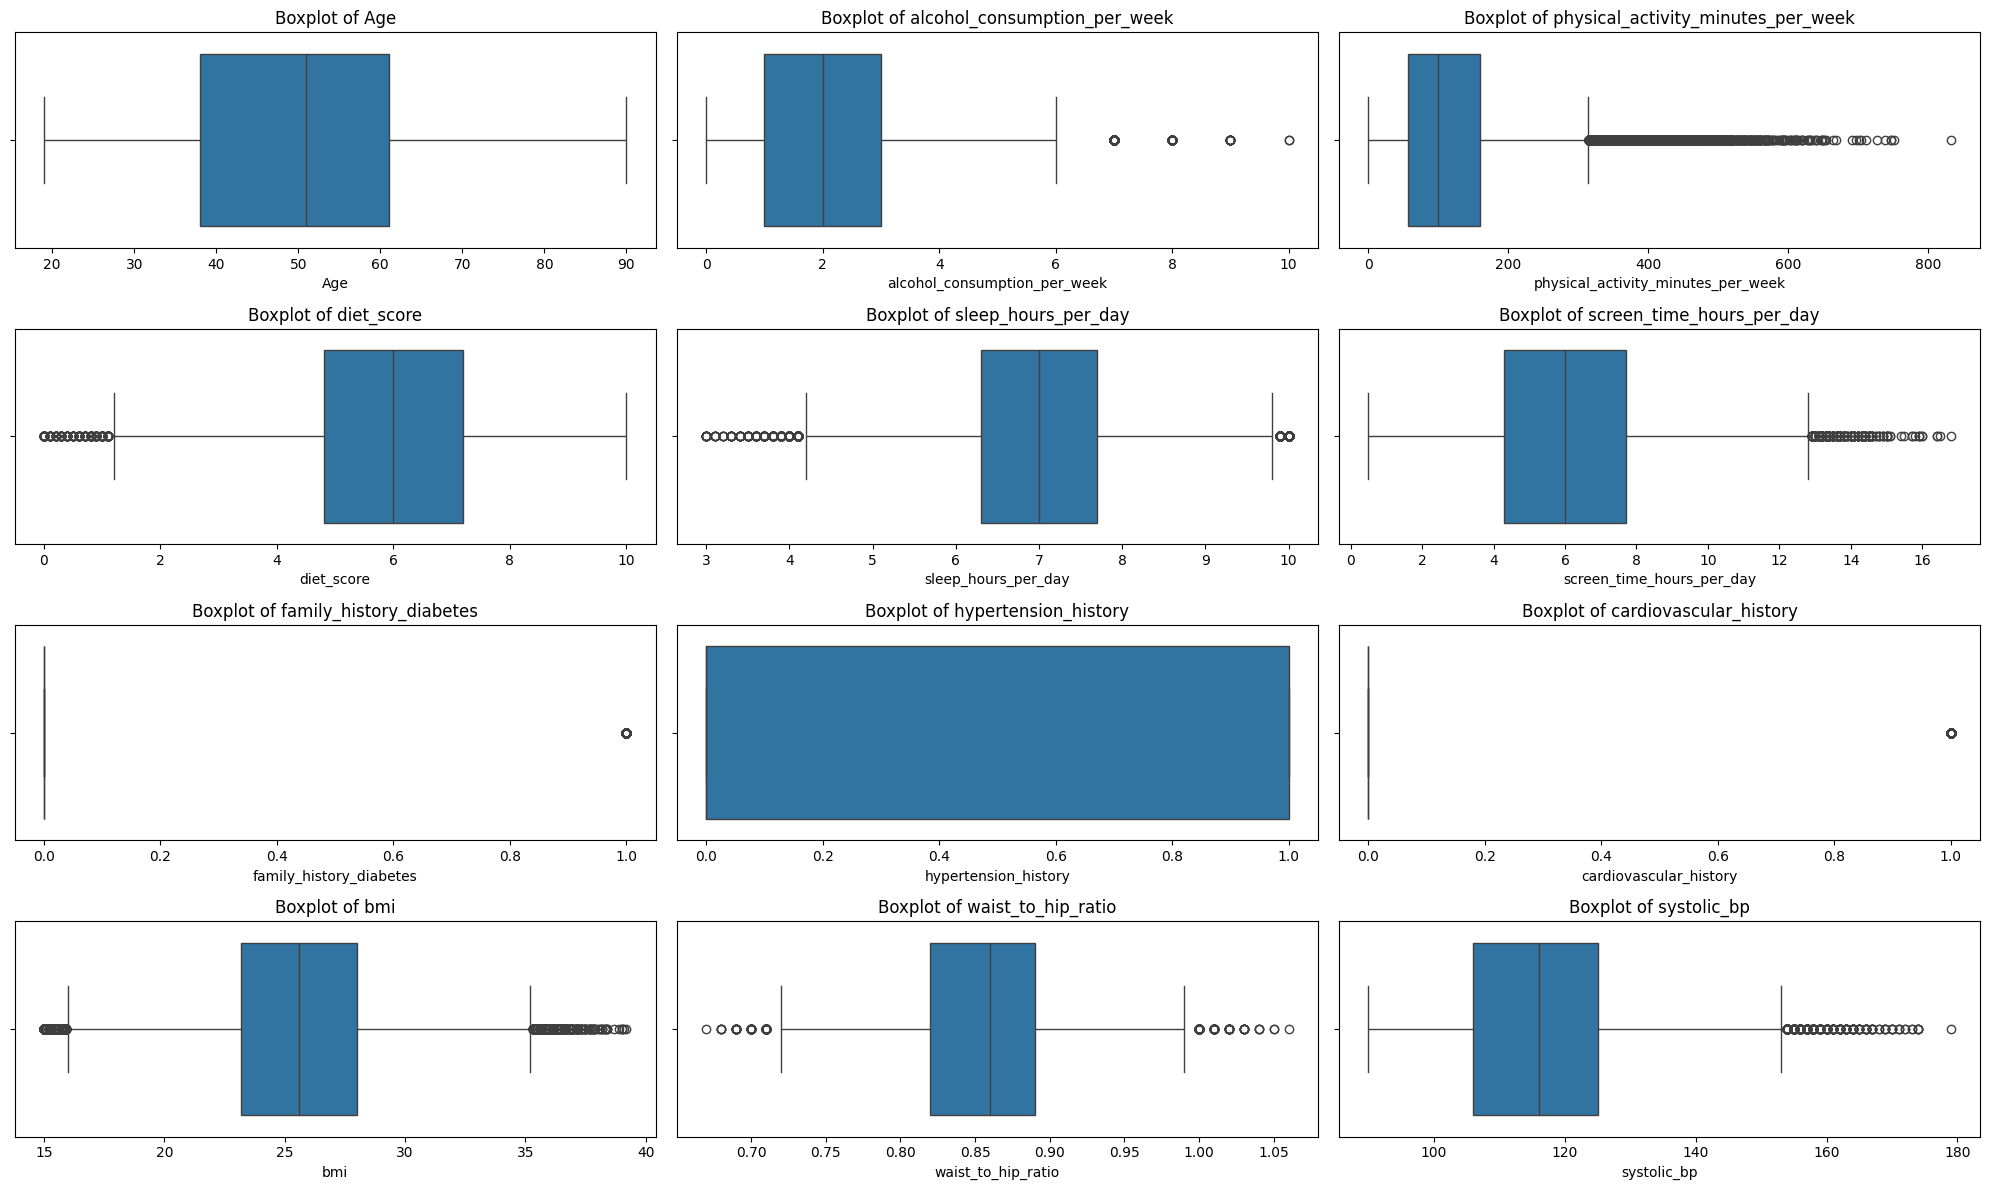

Boxplot visualization completed


In [18]:
plt.figure(figsize=(20, 12))

for i, col in enumerate(numeric_cols[:12], 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

print("Boxplot visualization completed")

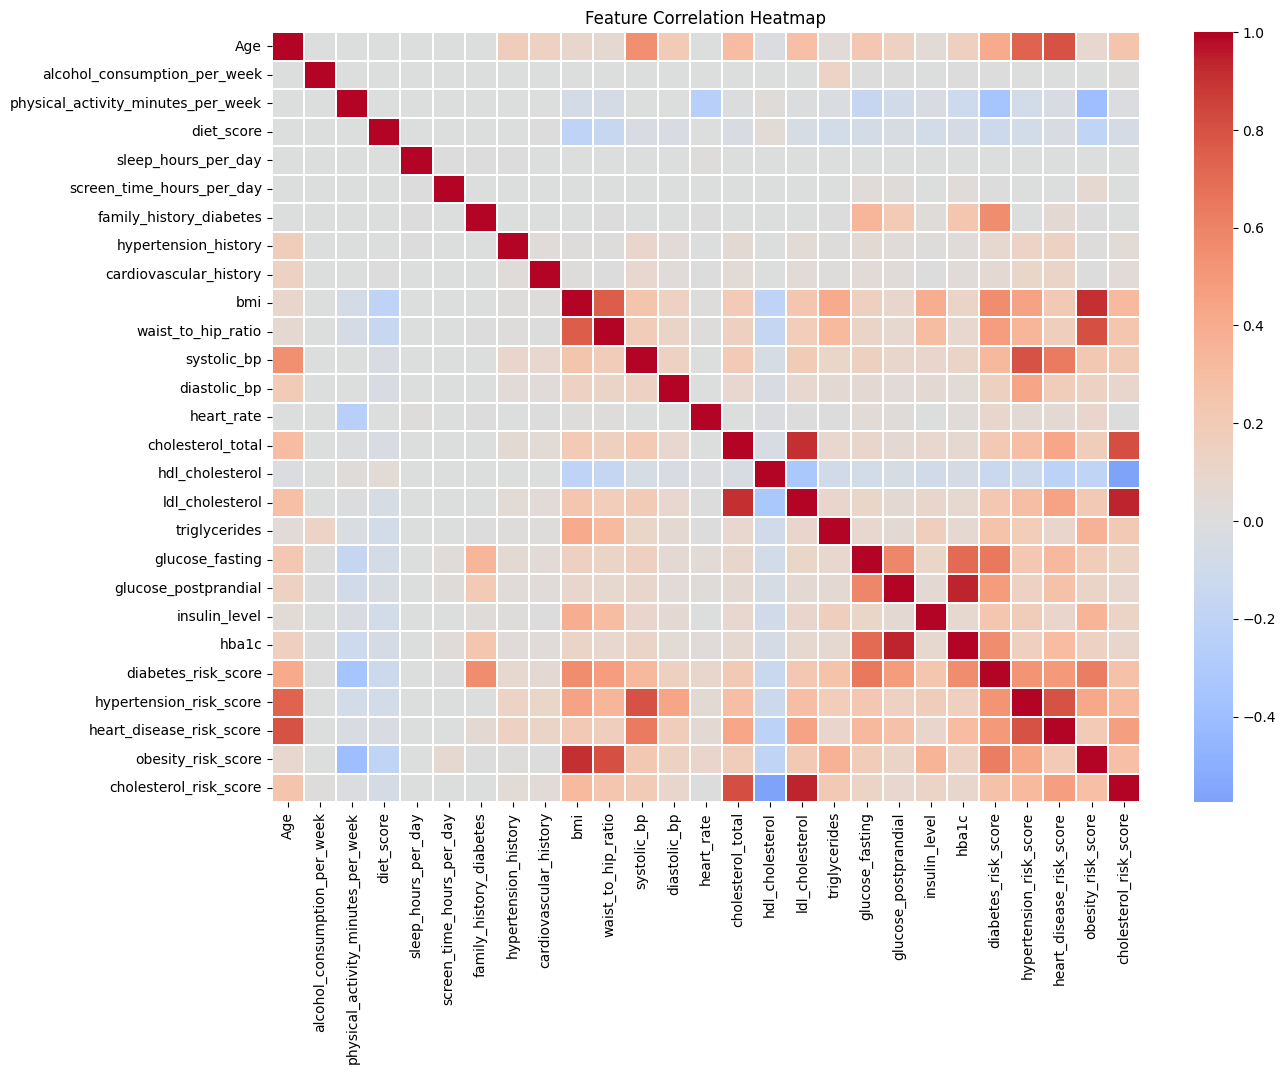

Correlation analysis completed


In [19]:
plt.figure(figsize=(14, 10))

corr_matrix = df[numeric_cols].corr()

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Feature Correlation Heatmap")
plt.show()

print("Correlation analysis completed")

In [20]:
print("Running data leakage checks...\n")

possible_id_cols = [col for col in df.columns if 'id' in col.lower()]

if possible_id_cols:
    print("Potential ID columns found:", possible_id_cols)
else:
    print("No obvious ID leakage columns detected")

if 'heart_disease_risk_score' in df.columns:
    target_corr = df[numeric_cols].corr()['heart_disease_risk_score'].abs().sort_values(ascending=False)
    display(target_corr.head(10))
    print("\nReview features with extremely high correlation (>0.95)")

Running data leakage checks...

Potential ID columns found: ['triglycerides']


,heart_disease_risk_score
heart_disease_risk_score,1.000000
hypertension_risk_score,0.799018
Age,0.798682
systolic_bp,0.633569
diabetes_risk_score,0.492923
cholesterol_risk_score,0.471368
ldl_cholesterol,0.450703
cholesterol_total,0.430790
glucose_fasting,0.328287
hba1c,0.304846



Review features with extremely high correlation (>0.95)


In [30]:
import os

os.makedirs(f"/artifacts", exist_ok=True)

clean_path = f"/artifacts/cleaned_data.csv"
df.to_csv(clean_path, index=False)

print("Cleaned dataset saved")

Cleaned dataset saved


In [33]:
from google.colab import files
files.download("/artifacts/cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
print("Final Shape:", df.shape)
print("Total Missing:", df.isnull().sum().sum())
print("Total Duplicates:", df.duplicated().sum())

df.sample(5)

Final Shape: (97297, 33)
Total Missing: 0
Total Duplicates: 0


,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,hypertension_risk_score,heart_disease_risk_score,obesity_risk_score,cholesterol_risk_score
12637,68,Female,Asian,Highschool,Low,Employed,Current,4,63,8.2,...,176,128,165,2.00,7.21,62.458134,49.384401,55.052529,50.188490,15.170933
14537,55,Female,Asian,Highschool,Lower-Middle,Employed,Never,2,261,3.7,...,116,106,147,6.03,6.19,28.331546,34.022775,30.899420,29.967714,22.336720
62623,37,Female,Black,Highschool,Middle,Employed,Current,4,203,9.5,...,206,119,175,3.85,6.98,29.485719,45.381899,32.868329,33.529727,27.833883
71171,69,Male,White,No formal,Upper-Middle,Employed,Never,3,74,5.1,...,181,110,183,12.99,6.70,46.321487,50.625342,44.508831,54.142467,28.810573
41498,58,Male,Asian,Postgraduate,Middle,Employed,Former,3,152,5.9,...,156,104,128,3.82,5.79,56.063463,43.844404,35.708353,49.483247,3.894019


## Notebook 01 Completed

The dataset has been thoroughly cleaned, validated, and analyzed.

Next Step → **Notebook 02: Advanced EDA**